# **Analysis of International Aircraft Movements in the UAE: 2018 to 2025**

## **Introduction to the Project:**

Dubai is one of the biggest aviation hubs in the world, connecting the East to the West in the same way Qatar and Turkey do, and Dubai International Airport (DXB) has been one of the busiest airports in the world. Dubai also plans to move its main operations to the Al Maktoum International Airport (DWC) over roughly the next decade, so it is useful to understand how flight activity has been changing.

<br>

This project analyses an open dataset from Bayanat.ae that contains monthly international flight arrivals and departures from 2018 to 2025 (eight full years). I first treated this data as flights at DXB. Official UAE totals show that it covers UAE airports as a whole, with DXB as the largest part (see the scope note under About the Dataset), so the analysis is framed around UAE aircraft movements. Using Python packages such as Pandas, NumPy, Matplotlib and seaborn, it looks at how flight movements changed over time, seasonal patterns, the impact of COVID-19, and the long-term trend.

## **Project Objectives:**

In this project, I aim to:


* Explore how flight volumes (in and out) in the UAE have changed from 2018 to 2025.

* Identify seasonal patterns in arrivals and departures.

* Identify any correlation between the number of flights arriving and departing.


* Analyse the impact of COVID-19 (if any) on aviation activity.

* Look at the long-term trend and what it suggests about future activity, as background to Dubai's airport expansion plans.

* Create new features to deepen insights.

* Present visualisations and their interpretations to communicate my findings clearly.

<br>

## **About the Dataset:**

The dataset used in this project is sourced from Bayanat.ae

Link to dataset - https://bayanat.ae/en/Datasets/Dataset-info?id=oTzaA0ZCi4mGo-L8dXHc3r9Dhlt4kATUnKBX6oS47jg


It has four fields:

1. Year (2018 - 2025)
2. Month (1 - 12)
3. Departing international flights (count)
4. Arriving international flights (count)

<br>

Although the dataset is quite simple, focusing on aircraft movements in the UAE can still offer us valuable insights like long-term trends, seasonal patterns, etc. This in turn helps us to assess Dubai's future expansion plans.

<br>

*Limitations:*

The dataset only provides us with monthly flight counts and does not include passenger numbers or capacity-related details. While this does limit what we can say about Dubai's expansion plans, we can still get a clear idea of how flight activity has changed over time.

<br>

*Scope note:*

The Bayanat description says these counts are international aircraft movements handled by the Sheikh Zayed Air Navigation Centre, excluding domestic movements and overflights, and the file has no airport column. I first read it as DXB only, but the numbers say otherwise. The UAE statistics centre (FCSC) reports 694,050 civil aircraft movements across all UAE airports in 2023, 771,800 in 2024 and 828,570 in 2025, against 694,130, 775,248 and 833,789 in this file. Dubai Airports reports 440,300 movements at DXB in 2024 and 454,800 in 2025, which is only about 55% to 57% of this file's totals for those years. So the file covers UAE airports as a whole, and DXB is the largest part of it.

<br>

## **Loading the Dataset:**

We will load/import the dataset using the Pandas library.

The Bayanat file has been updated since this analysis was first built and now runs to February 2026. The code below keeps the eight full years, January 2018 to December 2025, and leaves out the two months of 2026 because that year is incomplete. The data is on the sheet called "Data Set".

In [1]:
import pandas as pd

file_path = 'data/International Aircraft Movements.xlsx'

df = pd.read_excel(file_path, sheet_name='Data Set')

# Keep the eight full years, 2018 to 2025 (2026 is incomplete)
df = df[df.iloc[:, 0] <= 2025].reset_index(drop=True)

print("Dataset Layout and Columns:\n")
df.head()

Dataset Layout and Columns:



,Year / السنة,Month / الشهر,Departing international flights / الرحلات الدولية المغادرة,Arriving international flights / الرحلات الدولية القادمة
0,2018,1,28431,28392
1,2018,2,25000,25034
2,2018,3,28178,28209
3,2018,4,27062,27048
4,2018,5,26162,26168


## **Data Pre-Processing:**

In this section, the dataset is cleaned and prepared in a manner that makes it easy to work with and helps make analysis and interpreting easier.

<br>

### The following are the steps followed in the Pre-Processing:

<br>

**Step 1:** Restructure column headers to only have the English term, removing the Arabic term

<br>
    
As seen in the code above, when we load the dataset, each column header contains the English and Arabic terms for that particular value. While this is helpful, for this project we will only be working with the English term, as having the Arabic term along could cause some confusion, especially considering the Arabic script is from right to left, unlike English.

<br>

In [2]:
df.columns = df.columns.str.split('/').str[0].str.strip()
df.head()

,Year,Month,Departing international flights,Arriving international flights
0,2018,1,28431,28392
1,2018,2,25000,25034
2,2018,3,28178,28209
3,2018,4,27062,27048
4,2018,5,26162,26168


<br>

**Step 2:**  Check and deal with Null values (if any)

<br>

After having restructured the column headers, we will now check if the dataset contains any null (0) values. It is important to carry this out, as these values could hinder the analysis in a major way.

<br>

In [3]:
df.info()
print("\n")
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Year                             96 non-null     int64
 1   Month                            96 non-null     int64
 2   Departing international flights  96 non-null     int64
 3   Arriving international flights   96 non-null     int64
dtypes: int64(4)
memory usage: 3.1 KB




Year                               0
Month                              0
Departing international flights    0
Arriving international flights     0
dtype: int64

<br>

Using df.info() and df.isnull() we have confirmed that there are no null (0) values in any of the 96 rows in the dataset.

<br>

**Step 3:** Standardising column names by making them all lowercase.

<br>

While this step is not necesarry, we make all the column headers lowercase for consistency and standardisation.

<br>

In [4]:
df.columns = df.columns.str.lower()
df.head()

,year,month,departing international flights,arriving international flights
0,2018,1,28431,28392
1,2018,2,25000,25034
2,2018,3,28178,28209
3,2018,4,27062,27048
4,2018,5,26162,26168


<br>

**Step 4:** Rename columns 3 and 4 into a more standardised form.

<br>

Continuing with standardising the data, I will be renaming columns 3 and 4 to 'departing_flights' and 'arriving_flights' respectively, as the current names are slightly long and also has spaces between them.

In [5]:
df = df.rename(columns={"departing international flights":"departing_flights","arriving international flights":"arriving_flights"})

df.head()

,year,month,departing_flights,arriving_flights
0,2018,1,28431,28392
1,2018,2,25000,25034
2,2018,3,28178,28209
3,2018,4,27062,27048
4,2018,5,26162,26168


<br>

**Step 5:** Convert the numbers in the 'Month' column to their corresponding month names.

<br>

Reading and interpreting months from their respective order numbers can we quite tricky, and so we will be converting the month numbers to the month names.

<br>

In [6]:
month_map = {1:"January", 2:"February", 3:"March", 4:"April", 5:"May", 6:"June", 7:"July", 8:"August", 9:"September", 10:"October", 11:"November", 12:"December"}

df["month"] = df["month"].map(month_map)

df.head(13)

,year,month,departing_flights,arriving_flights
0,2018,January,28431,28392
1,2018,February,25000,25034
2,2018,March,28178,28209
3,2018,April,27062,27048
4,2018,May,26162,26168
5,2018,June,26145,26151
6,2018,July,28262,28270
7,2018,August,28326,28344
8,2018,September,26680,26708
9,2018,October,26662,26735


<br>

df.head(13) allows us to see the row after the first December (second January), confirming that all months have now been converted into their respective names.

<br>

**Step 6:** Create a 'total_flights' column.

<br>

The creation of this column helps us hold the monthly value for total flight volume (arrivals and departures).

<br>

In [7]:
df["total_flights"] = df["departing_flights"] + df["arriving_flights"]
df.head()

,year,month,departing_flights,arriving_flights,total_flights
0,2018,January,28431,28392,56823
1,2018,February,25000,25034,50034
2,2018,March,28178,28209,56387
3,2018,April,27062,27048,54110
4,2018,May,26162,26168,52330


<br>

**Step 7:** Create a proper date column using both the 'Year' and 'Month' columns.

<br>

In [8]:
df["date"] = pd.to_datetime(df["month"] + " " + df["year"].astype(str))
df.head()

/tmp/ipykernel_637/2773389354.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["month"] + " " + df["year"].astype(str))


,year,month,departing_flights,arriving_flights,total_flights,date
0,2018,January,28431,28392,56823,2018-01-01
1,2018,February,25000,25034,50034,2018-02-01
2,2018,March,28178,28209,56387,2018-03-01
3,2018,April,27062,27048,54110,2018-04-01
4,2018,May,26162,26168,52330,2018-05-01


<br>

While the date does show a singular day, as in the first of every month, it is still mapped to the monthly value. We need this data point as it will be important for our plotting.

<br>

## **Analysis:**

We now begin with our analysis of the dataset, where will aim to meet and get answers to the project objectives set earlier.

In brief the aim is to understand how flight activity has changed over time, look for any seasonal patterns, examine the impact of COVID-19 and also find long-term trends.

<br>

The following are the questions we look to answer:

<br>

### **Q1. How have total flight volumes changed from 2018 to 2025?**


In this section, we aim to see and understand what the flight volume trend has been like in the UAE between 2018 and 2025.

In [9]:
flights_yearly = df.groupby("year")[["arriving_flights", "departing_flights", "total_flights"]].sum()

flights_yearly = flights_yearly.reset_index()

flights_yearly

,year,arriving_flights,departing_flights,total_flights
0,2018,325304,325078,650382
1,2019,309000,308714,617714
2,2020,146148,145607,291755
3,2021,192122,192140,384262
4,2022,289065,289091,578156
5,2023,347025,347105,694130
6,2024,387681,387567,775248
7,2025,416920,416869,833789


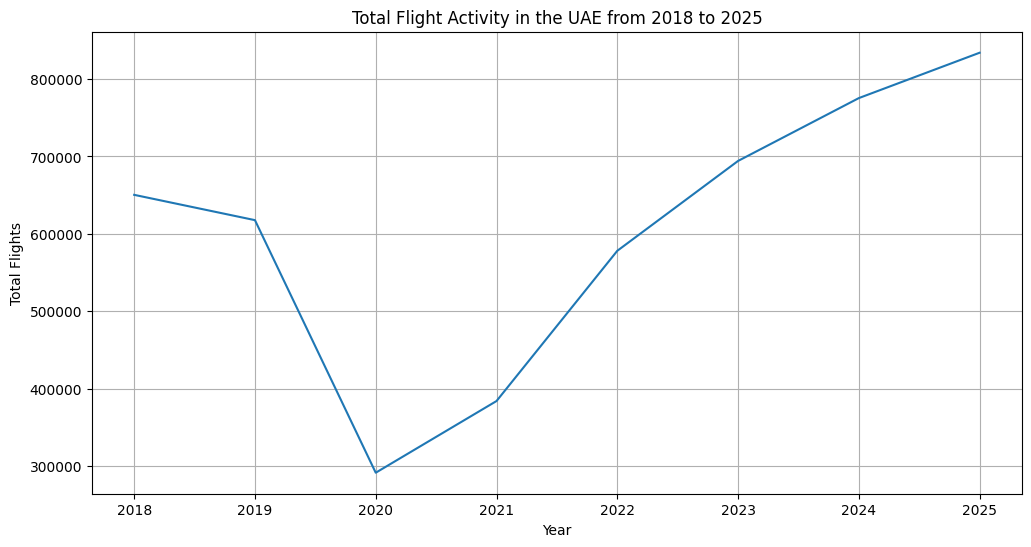

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(flights_yearly["year"], flights_yearly["total_flights"])

plt.xlabel("Year")
plt.ylabel("Total Flights")
plt.title("Total Flight Activity in the UAE from 2018 to 2025")

plt.grid(True)

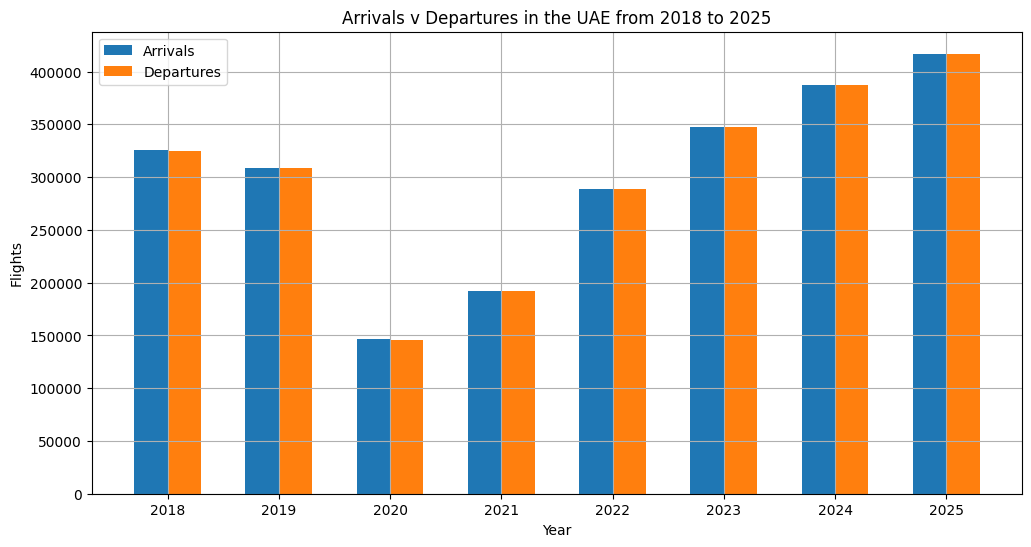

In [11]:
import numpy as np

x = np.arange(len(flights_yearly["year"]))

plt.figure(figsize=(12,6))

width = 0.3

plt.bar(x - width/2, flights_yearly["arriving_flights"], width, label="Arrivals")
plt.bar(x + width/2, flights_yearly["departing_flights"], width, label="Departures")

plt.xlabel("Year")
plt.ylabel("Flights")
plt.title("Arrivals v Departures in the UAE from 2018 to 2025")
plt.xticks(x, flights_yearly["year"])

plt.legend()
plt.grid(True)


<br>

**Inference:**

From the Table and Plot 1 above, we can see that flight volume in the UAE fell in 2019 and 2020, grew every year from 2021, and reached its highest level in 2025 (833,789 flights).

We also see in Plot 2 that the arrivals and departures numbers are neck and neck, with neither side ahead in every year. We will look more into this in Question 4.

<br>

There are 2 evident dips in the graph:

i) 2019 is a small dip, about 5% lower than 2018.

ii) 2020 sees a big dip due to COVID-19. We will discuss more about this in Question 3.

<br>

Apart from these dips, flight volume has increased year on year since 2021.

<br>

### **Q2. Seasonal Patterns (Monthly Trends Across All Years)**

The previous question showed us what the annual flight trends are like every year. In this section, we aim to see whether there are any seasonal trends in the data, i.e. whether there is a particular month or period that sees more flight volume in the year compared to the rest.

In [12]:
flights_monthly = df.groupby("month")[["arriving_flights", "departing_flights", "total_flights"]].sum()

flights_monthly = flights_monthly.reset_index()

flights_monthly

,month,arriving_flights,departing_flights,total_flights
0,April,181942,181891,363833
1,August,204608,204357,408965
2,December,227345,226947,454292
3,February,193932,193986,387918
4,January,214326,214567,428893
5,July,200127,200161,400288
6,June,183614,183819,367433
7,March,203280,203033,406313
8,May,183319,183297,366616
9,November,213360,213422,426782


<br>

From the code and table above, we were able to group total flight counts for each month across all the years.

But there is one evident issue. We can see that the months in the table are in alphabetical order and not in their chronological order. This can be problematic, because if we were to plot the data as it is, interpreting the graph could be difficult and wouldn't really show us seasonal data.

In order to fix this, we now have to map the months correctly using a dictionary and the map function, so that we get them in chronological order. This can be seen below.

<br>

In [13]:
month_map = {"January":1, "February":2, "March":3, "April":4, "May":5, "June":6, "July":7, "August":8, "September":9, "October":10, "November":11, "December":12}

flights_monthly["month_mapped"] = flights_monthly["month"].map(month_map)
flights_monthly = flights_monthly.sort_values("month_mapped")

flights_monthly

,month,arriving_flights,departing_flights,total_flights,month_mapped
4,January,214326,214567,428893,1
3,February,193932,193986,387918,2
7,March,203280,203033,406313,3
0,April,181942,181891,363833,4
8,May,183319,183297,366616,5
6,June,183614,183819,367433,6
5,July,200127,200161,400288,7
1,August,204608,204357,408965,8
11,September,197265,197058,394323,9
10,October,210147,209633,419780,10


<br>

Now that we have mapped the months correctly, we can go ahead and plot the data.

<br>

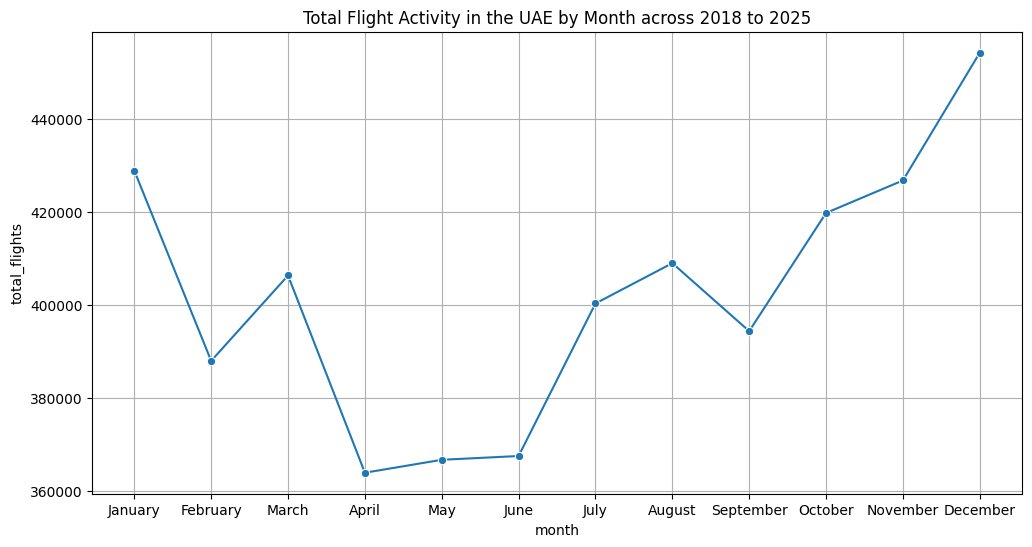

In [14]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(data=flights_monthly, x="month", y="total_flights", marker="o")

plt.title("Total Flight Activity in the UAE by Month across 2018 to 2025")

plt.grid(True)

<br>

We can also see monthly data on a yearly basis using subplots that show them side by side.

<br>

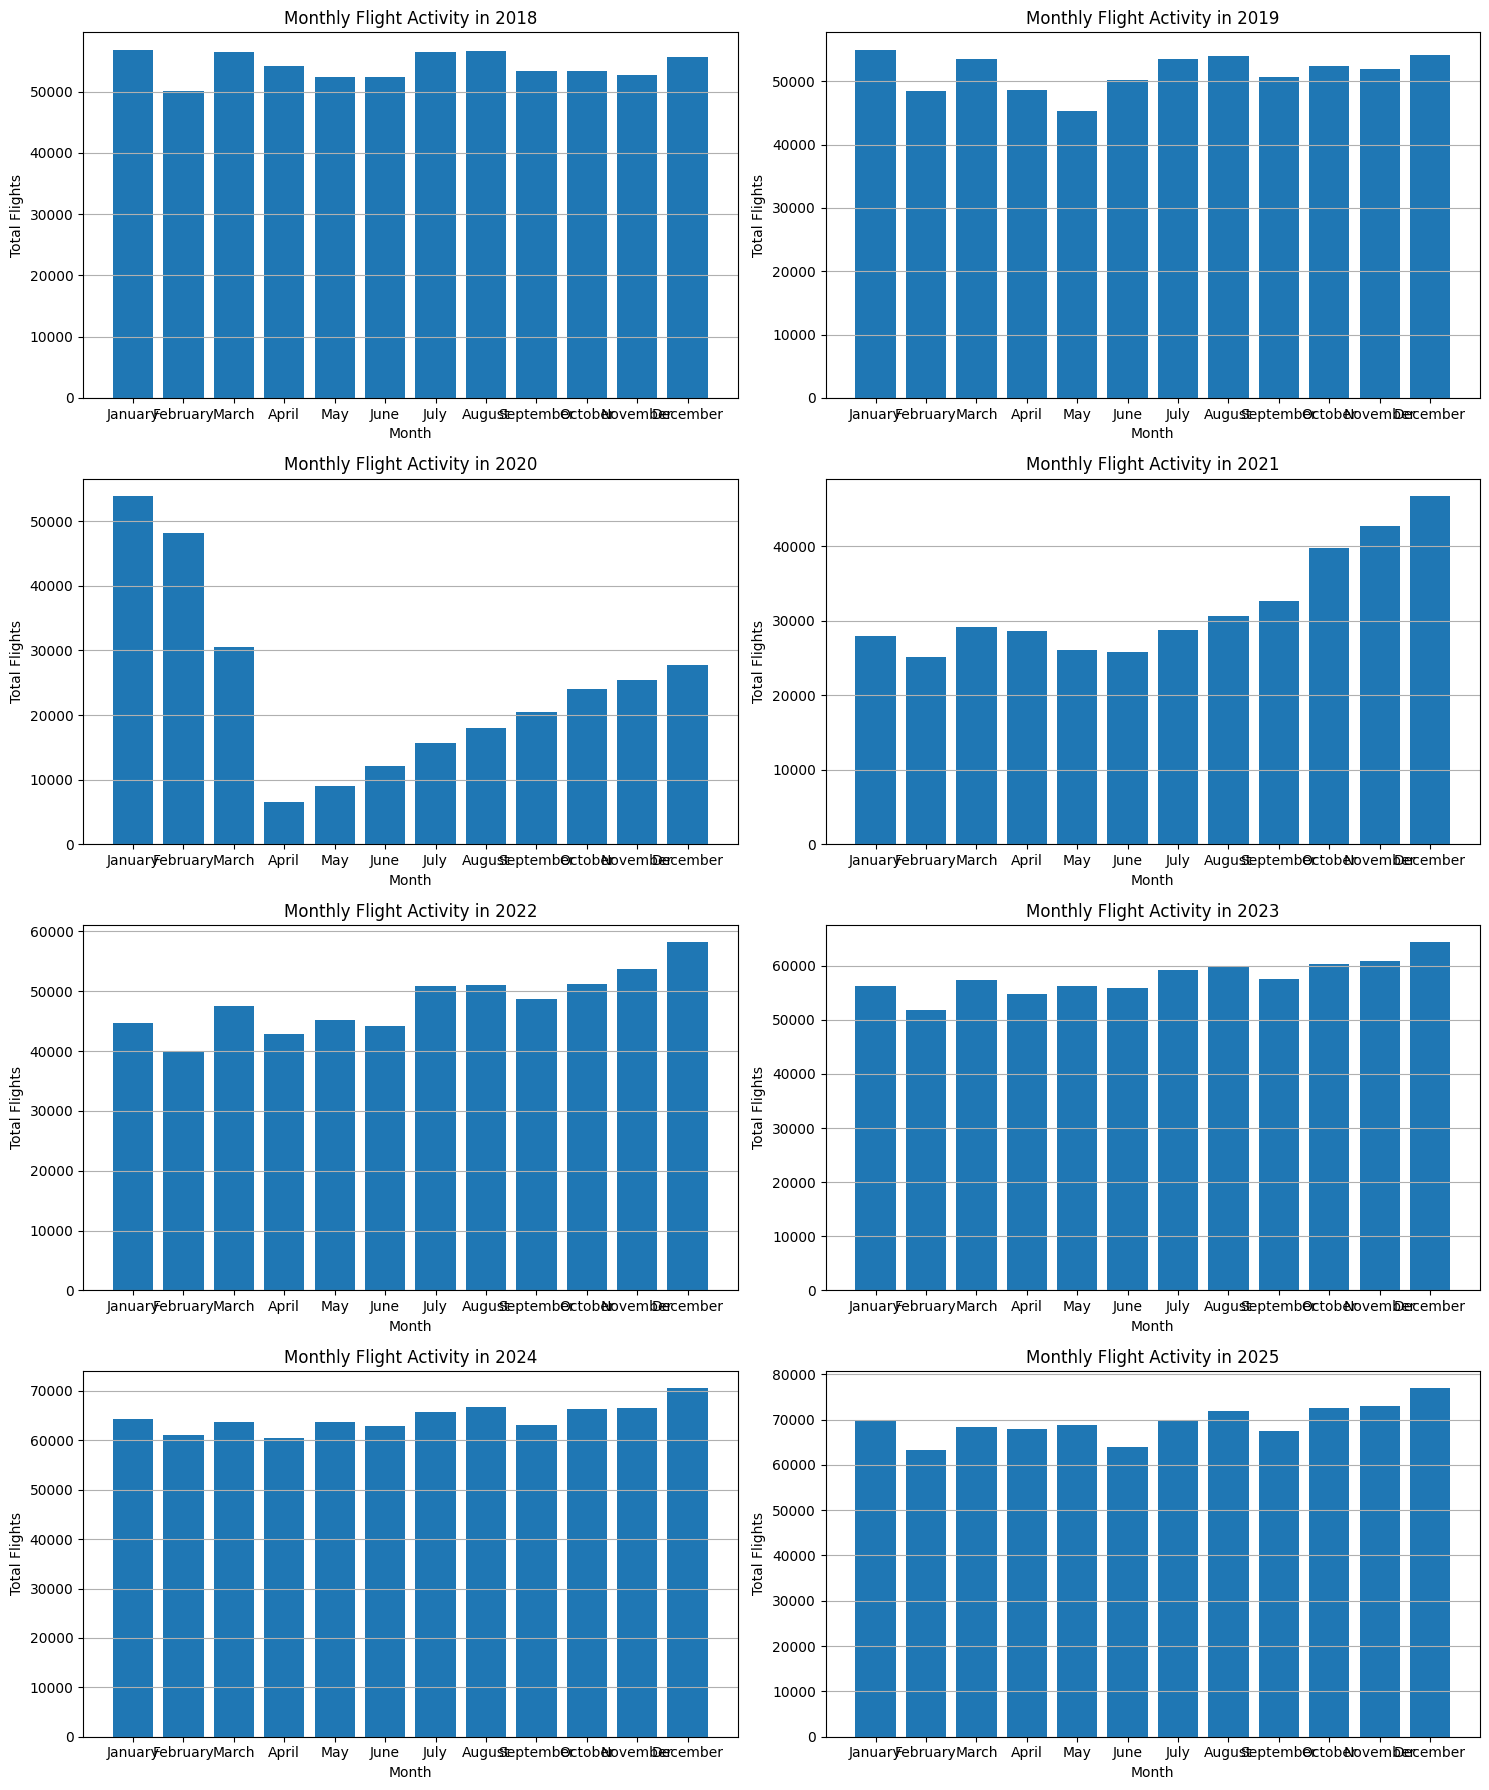

In [15]:
years = sorted(df["year"].unique())

plt.figure(figsize=(15,18))

for i, yr in enumerate(years, start=1):
  plt.subplot(4, 2, i)
  data_yearly = df[df["year"] == yr]

  plt.bar(data_yearly["month"], data_yearly["total_flights"])
  plt.xlabel("Month")
  plt.ylabel("Total Flights")
  plt.title(f"Monthly Flight Activity in {yr}")

  plt.grid(True, axis='y')
  plt.tight_layout()

<br>

**Inference:**

The table and plots above add up every year for each month. Every month now has 8 years in the totals, but two things still make the pooled numbers a poor guide to seasonality. The 2020 lockdown pulls April to June down, and in the recovery years (2021 and 2022) flights climbed month after month, which lifts the late-year months.

To get a fairer picture, the next step looks at each month's share of its own year, and only for years that were not affected by COVID.

<br>

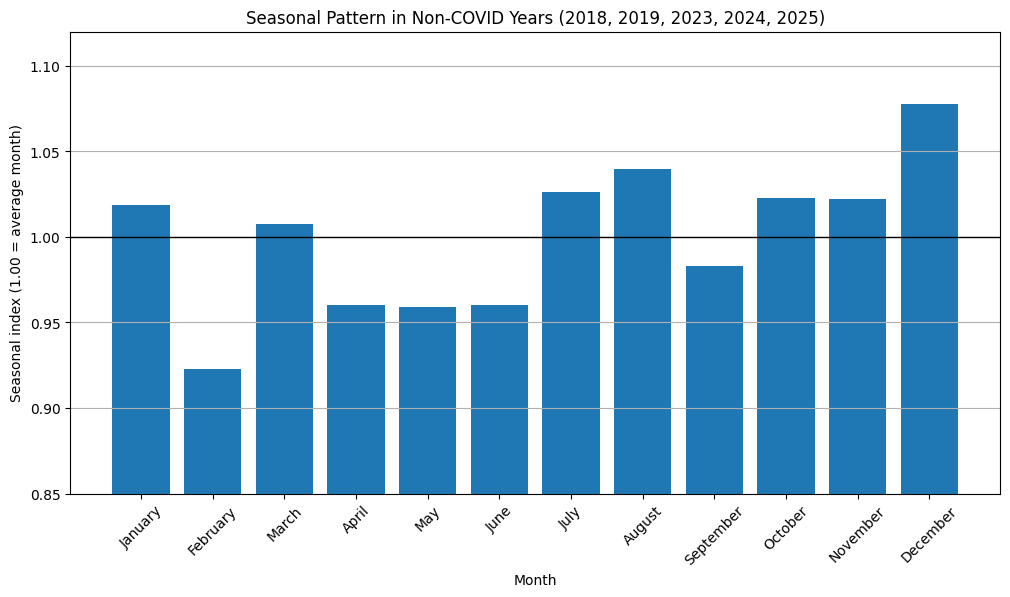

January      1.02
February     0.92
March        1.01
April        0.96
May          0.96
June         0.96
July         1.03
August       1.04
September    0.98
October      1.02
November     1.02
December     1.08
Name: index, dtype: float64

In [16]:
normal_years = [2018, 2019, 2023, 2024, 2025]

seasonal = df[df["year"].isin(normal_years)].copy()
seasonal["year_total"] = seasonal.groupby("year")["total_flights"].transform("sum")

# 1.00 means an average month for that year, 1.08 means 8% above average
seasonal["index"] = seasonal["total_flights"] / seasonal["year_total"] * 12

seasonal_index = seasonal.groupby(seasonal["date"].dt.month)["index"].mean()
seasonal_index.index = list(month_map.keys())

plt.figure(figsize=(12, 6))
plt.bar(seasonal_index.index, seasonal_index.values)
plt.axhline(1.0, color="black", linewidth=1)
plt.ylim(0.85, 1.12)
plt.xlabel("Month")
plt.ylabel("Seasonal index (1.00 = average month)")
plt.title("Seasonal Pattern in Non-COVID Years (2018, 2019, 2023, 2024, 2025)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()

seasonal_index.round(2)

<br>

**Inference (seasonality):**

Once the COVID years are left out, the seasonal pattern is real but small, roughly plus or minus 8% around an average month. December is the busiest month (about 8% above average), which fits the holiday period, although the data cannot say why. February is the quietest (about 8% below), partly because it has fewer days, and April to June sit about 4% below average. January to March is not a clear peak.

So the UAE runs at a high level with almost the same volume of flights all year round, with only a mild lift in December.

<br>

### **Q3. COVID 19 Impact (2018 - 2022)**

In this section, we will be looking into the impact COVID-19 had on flight volume in the UAE.

We will only be working within the period of 2018 to 2022, i.e. 2 years to either side of the main lockdown in 2020, as travel restrictions had been eased up on towards the second half of 2022 and we could see how the flight volume trend started to increase again from 2023 onwards in previous grpahs.

<br>

In [17]:
covid_years = [2018, 2019, 2020, 2021, 2022]

df_covid = df[df["year"].isin(covid_years)]

flights_covid = df_covid.groupby("year")["total_flights"].sum().reset_index()
flights_covid

,year,total_flights
0,2018,650382
1,2019,617714
2,2020,291755
3,2021,384262
4,2022,578156


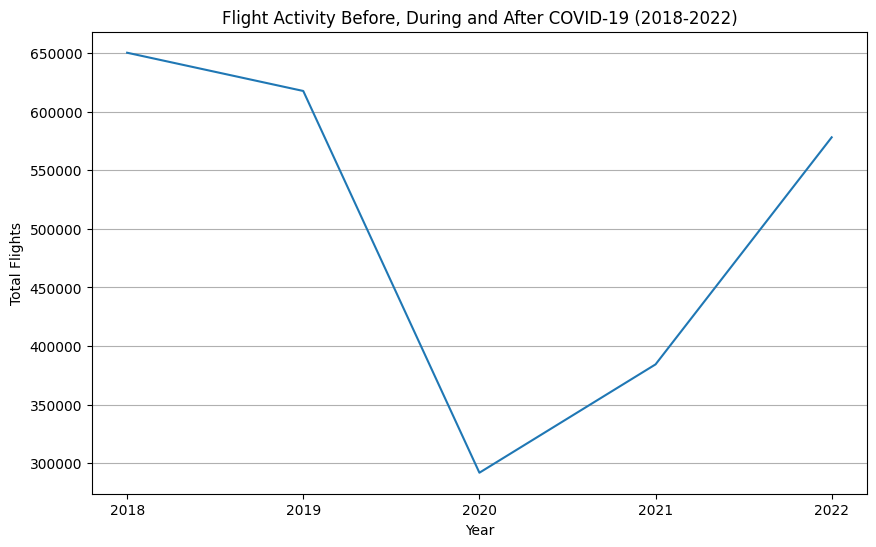

In [18]:
plt.figure(figsize=(10,6))

plt.plot(flights_covid["year"], flights_covid["total_flights"])

plt.xlabel("Year")
plt.ylabel("Total Flights")
plt.xticks(flights_covid["year"])
plt.title("Flight Activity Before, During and After COVID-19 (2018-2022)")

plt.grid(axis='y')

<br>

We can see from the plot above the huge impact the pandemic had on flight volume in 2020. UAE airports went from handling over 600 thousand flights a year to less than half of that in 2020 (291,755 flights to be exact).

We will now focus on the year 2020 alone to understand better.

We will first find the monthly flight volume average per year.

<br>

In [19]:
monthly_avg_pre_covid = df_covid.groupby("year")["total_flights"].mean().reset_index()
monthly_avg_pre_covid

,year,total_flights
0,2018,54198.500000
1,2019,51476.166667
2,2020,24312.916667
3,2021,32021.833333
4,2022,48179.666667


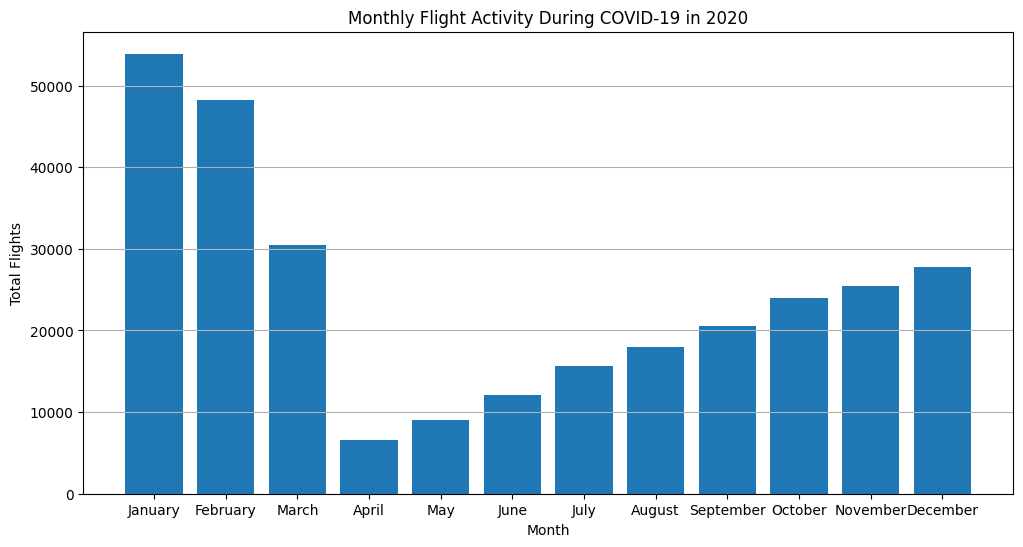

In [20]:
df_2020 = df[df["year"] == 2020]

plt.figure(figsize=(12,6))

plt.bar(df_2020["month"], df_2020["total_flights"])

plt.xlabel("Month")
plt.ylabel("Total Flights")
plt.title("Monthly Flight Activity During COVID-19 in 2020")

plt.grid(True, axis='y')

<br>

The graph shows accuracy in data as the first lockdown globally was initiated towards the end of March 2020 and early April 2020, and this is seen in the low stump at April 2020 and the months to follow.

<br>

**Inference:**

From the tables and plots above, we can see that UAE airports that handled at least 50,000 flights a month on average saw only about an eighth of that in April 2020. Even in the months to follow, the monthly flight count grew but at a very slow rate quite low as compared to the previous years monthly average due to strict travel laws and restrictions.


But operations seemed to pick up again towards 2022 as can be seen from the data and the graphs, and this was expected with the travel restrictions being pulled back on.


From the graphs above and even the ones in Question 1 and 2, we can say that flight activity recovered substantially after the pandemic. Annual flights in 2022 (578,156) were still below 2018 (650,382), but by 2023 they were above 2018 levels (694,130), and they were higher again in 2024 (775,248) and 2025 (833,789).

<br>

### **Q4. Correlation Between Arrivals & Departures**

In this section, we will be looking at whether there is any correlation between the arrival and departures count in the UAE.

<br>

In [21]:
df_corr = df[["arriving_flights", "departing_flights"]]
df_corr.corr()

,arriving_flights,departing_flights
arriving_flights,1.000000,0.999977
departing_flights,0.999977,1.000000


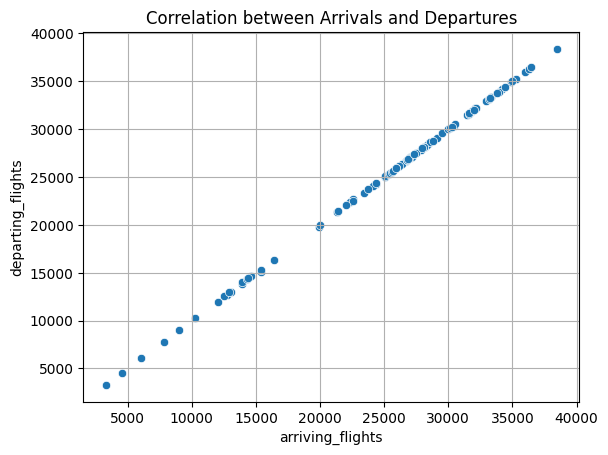

In [22]:
sns.scatterplot(data=df, x="arriving_flights", y="departing_flights")

plt.title("Correlation between Arrivals and Departures")

plt.grid(True)

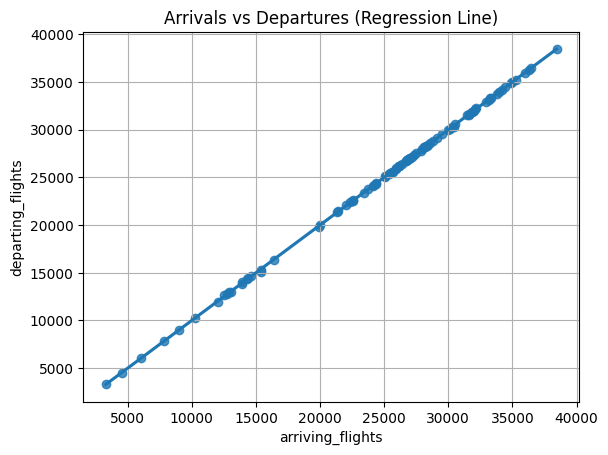

In [23]:
sns.regplot(x="arriving_flights", y="departing_flights", data=df)

plt.title("Arrivals vs Departures (Regression Line)")

plt.grid(True)

<br>

**Inference:**

From the table and seaborn scatter and regression plots above, we can see that there is a very strong correlation between the arrivals and departures count in the UAE.

Now while this correlation is expected, as any flight that arrives will have to depart, the consistent high volumes of both arrivals and departures help us better understand how large and active the UAE's airports are.

<br>

### **Q5. Long-Term Trend & Future Projection**

In this section, we look at what flight volume could be from 2026 onwards, as background to Dubai's expansion plans.

<br>

*Note on method:* I reworked this section after my first version. The COVID analysis in Q3 is unchanged, and the COVID years still show up in every plot below. The only thing that changed is how they feed into the projection. The first version averaged the year-on-year growth over all years, including the fall in 2020 and the rebound in 2021 and 2022, and compounded that one rate for seven years. In this version the COVID years are left out of the trend fit only, and the projection comes with a range instead of a single line.

The first version also had to estimate 2025 from its first three months (Q1 average x 12, which gave 805,648). The full year is in the data now (833,789), so no estimate is needed. For the record, that shortcut came out about 3% low.

<br>

**Step 1: Look at the growth rate that the first version used**

The first version took the average of the year-on-year growth rates across all years. Below are those rates, followed by a few other ways of summarising growth, to see how much the answer depends on the COVID years.

<br>

In [24]:
flights_yearly = df.groupby("year")[["total_flights"]].sum().reset_index()
totals = flights_yearly.set_index("year")["total_flights"]

covid_window = [2020, 2021, 2022]

flights_yearly["yoy_growth"] = flights_yearly["total_flights"].pct_change() * 100
print(flights_yearly[["year", "total_flights", "yoy_growth"]].round(1).to_string(index=False))
print()

# first version, reproduced: 2025 = Q1 average x 12 (only January to March 2025 was available then),
# then average all year-on-year rates
q1_2025 = df[(df["year"] == 2025) & (df["date"].dt.month <= 3)]["total_flights"].sum()
first_version_base = q1_2025 * 4

first_version_totals = totals.copy()
first_version_totals[2025] = first_version_base
first_version_rate = first_version_totals.pct_change().mean()

growth_options = pd.Series({
    "Average of all year-on-year rates (first version)": first_version_rate * 100,
    "Same average with only 2020 removed": flights_yearly.loc[flights_yearly["year"] != 2020, "yoy_growth"].mean(),
    "Compound growth 2018 to 2025 (COVID years not used)": ((totals[2025] / totals[2018]) ** (1 / 7) - 1) * 100,
}).round(1)

growth_options.to_frame("growth % per year")

 year  total_flights  yoy_growth
 2018         650382         NaN
 2019         617714        -5.0
 2020         291755       -52.8
 2021         384262        31.7
 2022         578156        50.5
 2023         694130        20.1
 2024         775248        11.7
 2025         833789         7.6



,growth % per year
Average of all year-on-year rates (first version),8.6
Same average with only 2020 removed,19.4
Compound growth 2018 to 2025 (COVID years not used),3.6


<br>

Two things stand out.

Removing only 2020 does not fix the average. It pushes it up to about 19%, because the rebound in 2021 (+32%) and 2022 (+50%) stays in. Those years are recovery from a low base, not normal growth. The rebound is also why the all-years average of about 8.6% is so much higher than the compound growth between 2018 and 2025 (about 3.6% a year), which does not touch the COVID years.

Growth has also been slowing since the recovery: about +20% in 2023, +12% in 2024 and +7.6% in 2025. An average of year-on-year rates mixes all of these regimes into one number, so it is a poor input for a seven-year projection.

Instead of averaging rates, I fit a straight trend line to the yearly totals, using only the years outside the COVID window (2018, 2019, 2023, 2024 and 2025). The COVID years are still plotted, they just do not pull the line.

<br>

**Step 2: Fit the trend and project 2026 to 2032**

Dubai's move to the new airport is described as a phased move over roughly the next decade, not a fixed date, so I use 2032 as a round end point for the projection and not as an official date.

The shaded band is a 95% prediction interval: the range in which a single future year's total would be expected to fall if the past pattern continues.

<br>

In [25]:
from scipy import stats

fit_data = flights_yearly[~flights_yearly["year"].isin(covid_window)]
x = fit_data["year"].values.astype(float)
y = fit_data["total_flights"].values
n = len(x)

fit = stats.linregress(x, y)
resid_sd = np.sqrt(((y - (fit.intercept + fit.slope * x)) ** 2).sum() / (n - 2))
t_crit = stats.t.ppf(0.975, n - 2)

def trend(year):
    return fit.intercept + fit.slope * year

def half_width(year):
    se = resid_sd * np.sqrt(1 + 1 / n + (year - x.mean()) ** 2 / ((x - x.mean()) ** 2).sum())
    return t_crit * se

projection_years = np.arange(2026, 2033)

projection_df = pd.DataFrame({
    "year": projection_years,
    "trend": trend(projection_years),
    "lower_95": trend(projection_years) - half_width(projection_years),
    "upper_95": trend(projection_years) + half_width(projection_years),
    "first_version": first_version_base * (1 + first_version_rate) ** np.arange(1, 8),
})

print(f"Points used in the fit: {n} (years {', '.join(str(int(v)) for v in x)})")
print(f"Trend: +{fit.slope:,.0f} flights per year, R-squared {fit.rvalue ** 2:.2f}")
print(f"2025 actual vs the fitted line: {totals[2025] / trend(2025) - 1:+.1%}")
print()
projection_df.round(0).astype(int)

Points used in the fit: 5 (years 2018, 2019, 2023, 2024, 2025)
Trend: +25,917 flights per year, R-squared 0.82
2025 actual vs the fitted line: +4.6%



,year,trend,lower_95,upper_95,first_version
0,2026,823104,643852,1002356,874751
1,2027,849020,657094,1040947,949781
2,2028,874937,668682,1081193,1031247
3,2029,900854,678935,1122773,1119701
4,2030,926771,688118,1165425,1215741
5,2031,952688,696438,1208938,1320019
6,2032,978605,704063,1253147,1433242


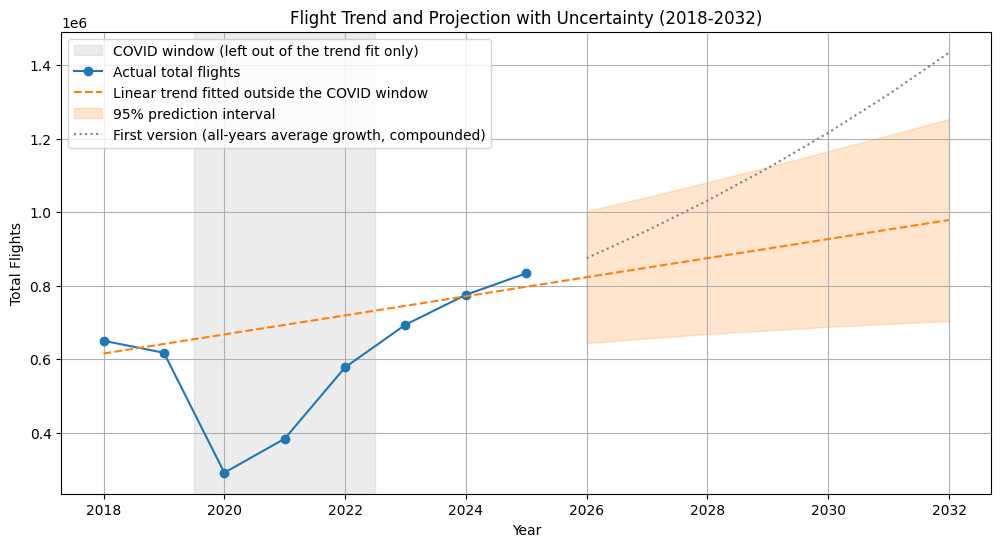

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.axvspan(2019.5, 2022.5, color="grey", alpha=0.15, label="COVID window (left out of the trend fit only)")

ax.plot(flights_yearly["year"], flights_yearly["total_flights"], marker="o", color="tab:blue",
        label="Actual total flights")

all_years = np.arange(2018, 2033)
ax.plot(all_years, trend(all_years), linestyle="--", color="tab:orange",
        label="Linear trend fitted outside the COVID window")
ax.fill_between(projection_df["year"], projection_df["lower_95"], projection_df["upper_95"],
                color="tab:orange", alpha=0.2, label="95% prediction interval")

ax.plot(projection_df["year"], projection_df["first_version"], linestyle=":", color="grey",
        label="First version (all-years average growth, compounded)")

ax.set_xlabel("Year")
ax.set_ylabel("Total Flights")
ax.set_title("Flight Trend and Projection with Uncertainty (2018-2032)")
ax.grid(True)
ax.legend(loc="upper left")
plt.show()

<br>

**Inference:**

Outside the COVID window, flight volume has a clear upward trend. The fitted line adds about 26,000 flights a year and gives roughly 980,000 flights for 2032, with a 95% range of about 700,000 to 1.25 million. The first version's figure of 1.43 million for 2032 sits above that whole range, mostly because it treated the 2021 and 2022 rebound as normal growth.

The line has limits. The 2025 total is about 5% above it, and the line puts 2026 slightly below 2025, so it probably understates the next few years. The range is wide because the fit rests on only five yearly points, and it only describes the past pattern continuing. These are UAE-wide counts, and the data has no passenger, gate or runway figures, so it says nothing about what capacity DXB, DWC or any other airport will need. I read the projection as a rough range, not a forecast.

<br>

## **Conclusion (Part 1 — UAE Aviation Trend):**

This analysis of international aircraft movements in the UAE from 2018 to 2025 shows a clear upward trend outside the COVID period, with 2025 the busiest year in the data (833,789 flights). Seasonality is mild: December is the busiest month, and most months sit within about 8% of an average month. COVID-19 cut annual flights by more than half in 2020, and volumes were back above 2018 levels by 2023 and higher again in 2024 and 2025. Arrivals and departures were almost perfectly correlated, as expected when every arrival is followed by a departure.

For the projection, the COVID years stay in the analysis but are left out of the trend fit. That gives roughly 980,000 flights by 2032, with a 95% range of about 700,000 to 1.25 million, which is well below what the first version of this notebook projected. The line probably understates the next few years, so the range is better read as a rough guide than a forecast.

The main limits are the short series, the lack of passenger and capacity data, and the scope of the dataset. The file covers UAE airports as a whole, not DXB alone, so it cannot show on its own whether moving operations from DXB to DWC is the right call. It does show that UAE flight activity has recovered from COVID and is still growing.

<br>

# **Part 2 — Dubai/DXB Capacity: Context for the DWC Expansion**

Part 1 answers how aviation activity across the UAE has changed since 2018. It cannot say much about Dubai's own airport, DXB, specifically, or about whether building Al Maktoum International (DWC) makes sense, because the Bayanat dataset has no per-airport breakdown and DXB is only the largest part of it (see the scope note above).

This second part uses Dubai Airports' own published figures for DXB and DWC instead, to look at the DWC question with data that is actually about those two airports.

<br>

### **2.1 DXB passenger demand, 2018-2025**

DXB does not publish a single downloadable dataset the way Bayanat does, so the table below is compiled by hand from Dubai Airports' own press releases and fact pages. Where Dubai Airports gave a figure directly, I used it; the one year they did not (2019) is filled from a third-party aggregator (roadgenius.com) and marked as such. Aircraft movements are only available for a few years, and I have left 2018 and 2022 blank rather than estimate them, since the passenger numbers are the more relevant figure for a capacity question anyway.

<br>

In [27]:
dxb = pd.DataFrame([
    {"year": 2018, "passengers_m": 89.1, "movements": None,   "passenger_source": "Dubai Airports"},
    {"year": 2019, "passengers_m": 86.4, "movements": 376598, "passenger_source": "roadgenius.com (gap-fill)"},
    {"year": 2020, "passengers_m": 25.9, "movements": 184713, "passenger_source": "Dubai Airports"},
    {"year": 2021, "passengers_m": 29.1, "movements": 236515, "passenger_source": "Dubai Airports"},
    {"year": 2022, "passengers_m": 66.1, "movements": None,   "passenger_source": "Dubai Airports"},
    {"year": 2023, "passengers_m": 87.0, "movements": 420849, "passenger_source": "Dubai Airports"},
    {"year": 2024, "passengers_m": 92.3, "movements": 440300, "passenger_source": "Dubai Airports"},
    {"year": 2025, "passengers_m": 95.2, "movements": 454800, "passenger_source": "Dubai Airports"},
])

dxb

,year,passengers_m,movements,passenger_source
0,2018,89.1,NaN,Dubai Airports
1,2019,86.4,376598.0,roadgenius.com (gap-fill)
2,2020,25.9,184713.0,Dubai Airports
3,2021,29.1,236515.0,Dubai Airports
4,2022,66.1,NaN,Dubai Airports
5,2023,87.0,420849.0,Dubai Airports
6,2024,92.3,440300.0,Dubai Airports
7,2025,95.2,454800.0,Dubai Airports


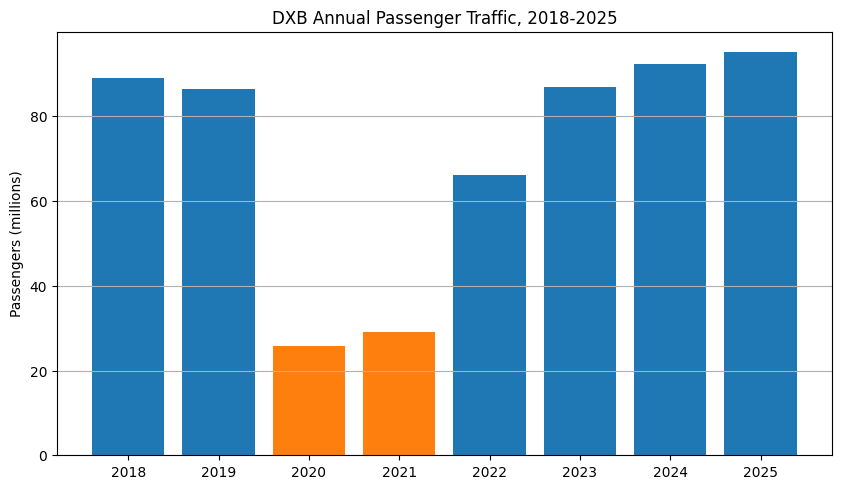

In [28]:
plt.figure(figsize=(10, 5.5))
colors = ["tab:orange" if y in (2020, 2021) else "tab:blue" for y in dxb["year"]]
plt.bar(dxb["year"].astype(str), dxb["passengers_m"], color=colors)
plt.ylabel("Passengers (millions)")
plt.title("DXB Annual Passenger Traffic, 2018-2025")
plt.grid(True, axis="y")
plt.show()

<br>

**Inference:**

DXB's passenger numbers follow the same shape as the UAE-wide movement counts in Part 1: a small dip in 2019, a collapse in 2020-2021 during COVID, and a recovery that overtakes 2018 by 2023. 2025 was DXB's busiest year on record at 95.2 million passengers, about 7% above its previous peak in 2018.

<br>

### **2.2 DXB's capacity versus DWC's planned scale**

The number that matters for the DWC question is not how many passengers DXB handled, but how close that is to what DXB can physically handle. Dubai Airports' CEO stated in September 2026 that DXB's maximum infrastructure capacity is around 115 million passengers a year, and separately that DXB is forecast to reach 100 million by the end of 2027 - a traffic milestone, not the capacity ceiling itself. I use the 115 million figure here.

DWC's current passenger terminal, opened in 2018, has a stated capacity of 26.5 million a year. Its approved Phase II expansion is planned to add 150 million a year of capacity in its first stage (early 2030s), rising to an ultimate capacity of 260 million a year across five runways.

<br>

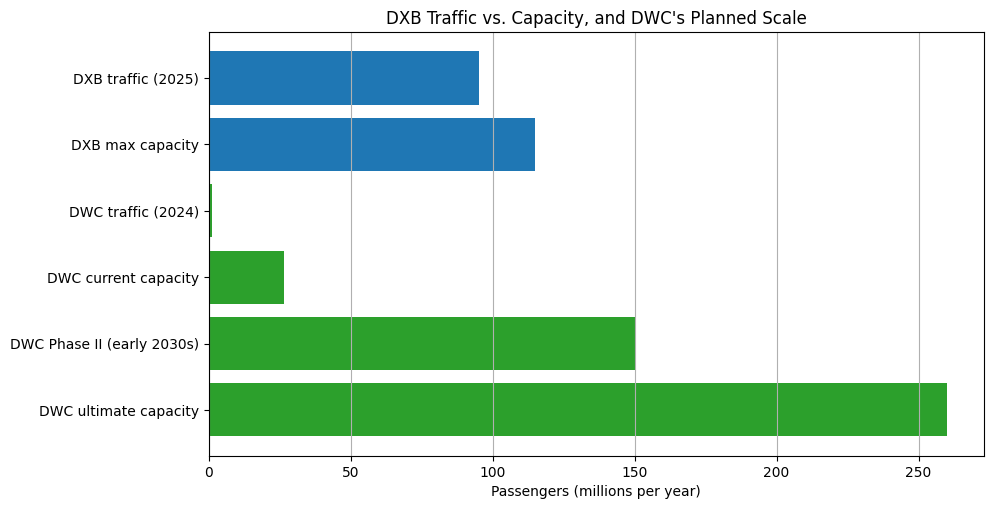

,label,value,group
0,DXB traffic (2025),95.2,DXB
1,DXB max capacity,115.0,DXB
2,DWC traffic (2024),1.1,DWC
3,DWC current capacity,26.5,DWC
4,DWC Phase II (early 2030s),150.0,DWC
5,DWC ultimate capacity,260.0,DWC


In [29]:
capacity = pd.DataFrame([
    {"label": "DXB traffic (2025)",         "value": 95.2,  "group": "DXB"},
    {"label": "DXB max capacity",           "value": 115,   "group": "DXB"},
    {"label": "DWC traffic (2024)",         "value": 1.1,   "group": "DWC"},
    {"label": "DWC current capacity",       "value": 26.5,  "group": "DWC"},
    {"label": "DWC Phase II (early 2030s)", "value": 150,   "group": "DWC"},
    {"label": "DWC ultimate capacity",      "value": 260,   "group": "DWC"},
])

colors = {"DXB": "tab:blue", "DWC": "tab:green"}
plt.figure(figsize=(10, 5.5))
plt.barh(capacity["label"], capacity["value"], color=[colors[g] for g in capacity["group"]])
plt.xlabel("Passengers (millions per year)")
plt.title("DXB Traffic vs. Capacity, and DWC's Planned Scale")
plt.gca().invert_yaxis()
plt.grid(True, axis="x")
plt.show()

capacity

<br>

**Inference:**

DXB's 2025 traffic of 95.2 million sits at roughly 83% of its stated 115 million maximum capacity: a well-utilised airport with room left, not one that has run out of room. DWC, by contrast, currently handles a small fraction of DXB's volume (about 1% of DXB's 2025 traffic) but is being built out to a scale DXB's own ceiling cannot reach: 150 million in its first phase alone, and up to 260 million eventually.

<br>

### **2.3 What this tells us, and what it does not**

Together, the two parts of this project show sustained growth in UAE aviation activity since the COVID recovery (Part 1), and specifically strong, still-growing demand at DXB, which reached a record 95.2 million passengers in 2025 against a stated maximum capacity of about 115 million (Part 2). DWC currently carries a small share of that traffic but is being expanded well beyond DXB's own ceiling, to 150 million passengers in its first phase and up to 260 million eventually.

That is evidence of real and growing demand, and of a deliberate move to build capacity beyond what DXB can ever hold. It is not evidence that the DWC investment is the right call in economic or operational terms. Answering that would need things this project does not have: long-term demand forecasts, the cost of the expansion against alternatives, and how Dubai's air connectivity needs are expected to change. What this project can say is that the demand and capacity context behind DWC is real, not that the decision itself is justified.

<br>